<a href="https://colab.research.google.com/github/lorenzogenera/Molecular_dynamics_sims/blob/main/2d_molecular_dynamics_sims.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **2D Molecular Dynamics**

A Python implementation of a 2D molecular dynamics simulator for argon atoms interacting through the Lennard-Jones potential.

This notebook works through the following short studies:

1. The LJ potential and force, with numerical root-finding to locate the equilibrium distance and contact distance.
2. Two-particle oscillation, comparing energy conservation under Euler vs RK2 integration.
3. Velocity Verlet as a symplectic integrator, with long-time energy behavior.
4. A nine-particle gas in a reflective box, tracking kinetic, potential, and total energy.
5. The Maxwell-Boltzmann speed distribution and temperature scaling.
6. Pressure measured from wall collisions, compared against the ideal-gas law (agrees to within ~4%).

Only `numpy` and `matplotlib` are used. The notebook is self-contained.

In [ ]:
# Lightweight integrators, inlined so the notebook is self-contained.
class myode:
    @staticmethod
    def move_Euler(diffeq, y, dt):
        return y + diffeq(y) * dt

    @staticmethod
    def move_RK2(diffeq, y, dt):
        k1 = diffeq(y)
        k2 = diffeq(y + k1 * dt)
        return y + 0.5 * (k1 + k2) * dt

    @staticmethod
    def move_Verlet(accel_fn, y, dt):
        # Velocity Verlet for second-order Newton systems.
        # y is laid out as [positions..., velocities...] with the two halves equal in length.
        # accel_fn(positions_flat) returns acceleration of matching shape.
        n = len(y) // 2
        pos = y[:n]
        vel = y[n:]
        a       = accel_fn(pos)
        vel_h   = vel + 0.5 * a * dt
        pos_new = pos + vel_h * dt
        a_new   = accel_fn(pos_new)
        vel_new = vel_h + 0.5 * a_new * dt
        return np.concatenate([pos_new, vel_new])

## Background Physics Information

We model argon atoms in 2D using the **Lennard-Jones (LJ) potential**:

$$U_{LJ}(r) = 4\epsilon\left[\left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^{6}\right]$$

The scalar force on one particle due to the other (positive = repulsive) is:

$$F_{LJ}(r) = -\frac{dU}{dr} = -4\epsilon\left[-\frac{12\sigma^{12}}{r^{13}} + \frac{6\sigma^{6}}{r^7}\right]$$

For a pair of particles separated by vector $(\Delta x, \Delta z)$, the force on particle 1 is

$$\vec{F}_1 = F_{LJ}(r)\cdot\frac{(\Delta x,\,\Delta z)}{r}$$

and $\vec{F}_2 = -\vec{F}_1$ by Newton's third law.

**State vector** for $N$ particles:

$$\mathbf{y} = [x_1, z_1,\; x_2, z_2,\; \ldots,\; v_{x1}, v_{z1},\; v_{x2}, v_{z2},\; \ldots]$$

so `y[0:2N]` holds positions and `y[2N:4N]` holds velocities.

**Total mechanical energy** (conserved):

$$E = \underbrace{\frac{1}{2}m\sum_i (v_{xi}^2 + v_{zi}^2)}_{KE} + \underbrace{\sum_{i<j} U_{LJ}(r_{ij})}_{PE}$$

**Temperature** from equipartition (2D, 2 translational degrees of freedom per particle):

$$\frac{1}{2}m\langle v^2 \rangle = k_B T \qquad \Longrightarrow \qquad T = \frac{m\langle v^2\rangle}{2k_B}$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Physical parameters for argon
epsilon = 4e-4 * 27.211 * 1.6e-19   # J
bohr    = 0.53e-10                   # m
sigma   = 2.4 * bohr                 # m
mass    = 40e-3 / 6.02e23            # kg
kB      = 1.38e-23                   # J/K
R       = 10 * bohr                  # box half-width

# Timestep from the harmonic approximation near the LJ minimum
k_eff  = 4 * epsilon * 18 / 2**(1/3) / sigma**2
omega  = np.sqrt(k_eff / mass)
period = 2 * np.pi / omega
dt     = 0.01 * period

print(f"sigma    = {sigma/bohr:.3f} bohr")
print(f"r_min    = {2**(1/6)*sigma/bohr:.3f} bohr  (analytical: 2^(1/6) * sigma)")
print(f"Period   = {period:.3e} s")
print(f"dt       = {dt:.3e} s")

sigma    = 2.400 bohr
r_min    = 2.694 bohr  (analytical: 2^(1/6) * sigma)
Period   = 6.530e-13 s
dt       = 6.530e-15 s


## **Lennard-Jones Potential and Root-Finding**

The LJ functions and bisection:

1. Implemented `flj(r)`, which returns the scalar LJ force $F(r)$, and `bisection(f, a, b)`.
2. Plotted $U_{LJ}(r)$ and $F_{LJ}(r)$ vs $r/\sigma$ for $r \in [0.85\sigma,\; 3.5\sigma]$, with a dashed horizontal line at $y = 0$ and labeled axes.
3. Found the two zeros of the LJ functions:
    - The LJ force has a zero at $r = r_{\min}$, the equilibrium separation.
    - The LJ potential also has a zero, at $r = \sigma$ — the point where the interaction switches from repulsive to attractive.

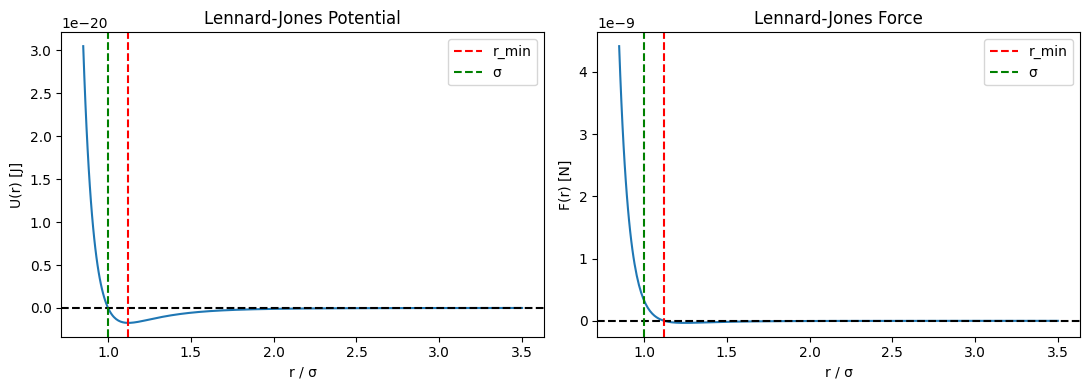

F(r) = 0  =>  r_min (bisection)  = 1.1224441528 σ
              r_min (analytical) = 1.1224620483 σ
              error              = 1.79e-05 σ

U(r) = 0  =>  σ (bisection)  = 2.3999816895 bohr
              σ (exact)      = 2.4000000000 bohr
              error          = 1.83e-05 bohr


In [ ]:
def ulj(r):
    return 4 * epsilon * ((sigma/r)**12 - (sigma/r)**6)

def flj(r):
    return -4 * epsilon * (-12 * sigma**12 / r**13 + 6 * sigma**6 / r**7)

def bisection(f, a, b, tol=1e-14):
    while b - a > tol:
        mid = (a + b) / 2
        if f(a) * f(mid) < 0:
            b = mid
        else:
            a = mid
    return (a + b) / 2

# Plot U(r) and F(r)
r_vals = np.linspace(0.85*sigma, 3.5*sigma, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(r_vals/sigma, ulj(r_vals))
axes[0].axhline(0, linestyle='--', color='k')
axes[0].axvline(2**(1/6), linestyle='--', color='r', label='r_min')
axes[0].axvline(1, linestyle='--', color='g', label='σ')
axes[0].set_xlabel('r / σ')
axes[0].set_ylabel('U(r) [J]')
axes[0].set_title('Lennard-Jones Potential')
axes[0].legend()

axes[1].plot(r_vals/sigma, flj(r_vals))
axes[1].axhline(0, linestyle='--', color='k')
axes[1].axvline(2**(1/6), linestyle='--', color='r', label='r_min')
axes[1].axvline(1, linestyle='--', color='g', label='σ')
axes[1].set_xlabel('r / σ')
axes[1].set_ylabel('F(r) [N]')
axes[1].set_title('Lennard-Jones Force')
axes[1].legend()

plt.tight_layout()
plt.show()

# Root-finding
r_min_num  = bisection(flj, 0.5*sigma, 2*sigma)
r_min_anal = 2**(1/6) * sigma
print(f"F(r) = 0  =>  r_min (bisection)  = {r_min_num/sigma:.10f} σ")
print(f"              r_min (analytical) = {r_min_anal/sigma:.10f} σ")
print(f"              error              = {abs(r_min_num - r_min_anal)/sigma:.2e} σ")

sigma_num = bisection(ulj, 0.5*sigma, 2*sigma)
print(f"\nU(r) = 0  =>  σ (bisection)  = {sigma_num/bohr:.10f} bohr")
print(f"              σ (exact)      = {sigma/bohr:.10f} bohr")
print(f"              error          = {abs(sigma_num - sigma)/bohr:.2e} bohr")

## Q & A (LJ):

**Questions:**

1. What does $r_{\min}$ represent physically for two argon atoms?
2. What does $\sigma$ represent?
3. At $r = \sigma$, are the atoms attracting or repelling each other?
4. How can you tell from the force plot?

**Answers:**

1. $r_{\min}$ represents the equilibrium separation distance, which is the distance at which the atoms feel no net force, because the attractive and repulsive contributions cancel out.

2. $\sigma$ represents the contact diameter, or the separation at which the potential energy is 0. It roughly indicates the size of an argon atom.

3. $\sigma = 2.4$ bohr is smaller than $r_{\min} \approx 2.7$ bohr. Since the atoms are closer together than the equilibrium distance, they repel each other.

4. A positive radial force means the force points outward, so each atom is pushed away from the other. The force curve crosses zero around $r = 1.12 \sigma$ (the equilibrium separation). For $r < r_{\min}$, the force is positive or repulsive. At $r = \sigma$ specifically, $r/r_{\min} < 1$, so the LJ force is well above zero.

## **Two-Particle Dynamics and Energy Conservation: Euler vs RK2**

Simulation of two argon atoms starting near their equilibrium separation.

**Initial conditions:** particle 1 at $(-r_{\min}/2 - 0.3\,\text{bohr},\; 0)$, particle 2 at $(+r_{\min}/2 + 0.3\,\text{bohr},\; 0)$, both at rest. This slight displacement from equilibrium causes them to oscillate.

1. Implemented `calc_forces_2(position)` and `diffeq_2(y)`.
2. Simulated for 300 oscillation periods with $dt = 0.01 \times$ period using both RK2 and Euler.
3. Tracked the total energy $E = KE + PE$ at each step for both methods.
4. Plotted $E(t)$ for both methods on the same graph (time in units of period).
5. Computed the fractional energy drift $(E_{\rm final} - E_0)/|E_0|$ for each method.

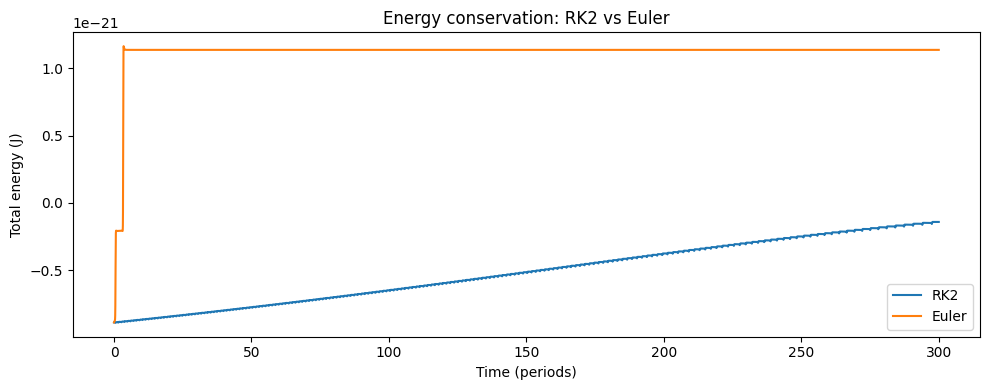

E0 = -8.8633e-22 J
RK2   fractional drift: 8.41e-01
Euler fractional drift: 2.28e+00


In [ ]:
r_min = 2**(1/6) * sigma
nparticles_2 = 2

def calc_forces_2(position):
    x1, z1 = position[0]
    x2, z2 = position[1]
    r12 = np.sqrt((x1 - x2)**2 + (z1 - z2)**2)
    f_scalar = flj(r12)
    fx1 = f_scalar * (x1 - x2) / r12
    fz1 = f_scalar * (z1 - z2) / r12
    return np.array([[fx1, fz1], [-fx1, -fz1]])

def diffeq_2(y):
    position = y[0:4].reshape(2, 2)
    forces = calc_forces_2(position)
    a = forces / mass
    return np.concatenate([y[4:], a.flatten()])

def total_energy_2(y):
    vx1, vz1, vx2, vz2 = y[4], y[5], y[6], y[7]
    KE = 0.5 * mass * (vx1**2 + vz1**2 + vx2**2 + vz2**2)
    r12 = np.sqrt((y[0]-y[2])**2 + (y[1]-y[3])**2)
    PE  = ulj(r12)
    return KE + PE

y0 = np.array([-(r_min/2 + 0.3*bohr), 0.0,
                (r_min/2 + 0.3*bohr), 0.0,
                0.0, 0.0, 0.0, 0.0])

t_range_2 = np.arange(0, 300 * period, dt)

y = y0.copy()
E_rk2 = []
for _ in t_range_2:
    y = myode.move_RK2(diffeq_2, y, dt)
    E_rk2.append(total_energy_2(y))

y = y0.copy()
E_euler = []
for _ in t_range_2:
    y = myode.move_Euler(diffeq_2, y, dt)
    E_euler.append(total_energy_2(y))

E0 = total_energy_2(y0)
t_periods = t_range_2 / period

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_periods, E_rk2, label='RK2')
ax.plot(t_periods, E_euler, label='Euler')
ax.set_xlabel('Time (periods)')
ax.set_ylabel('Total energy (J)')
ax.set_title('Energy conservation: RK2 vs Euler')
ax.legend()
plt.tight_layout()
plt.show()

print(f"E0 = {E0:.4e} J")
print(f"RK2   fractional drift: {(E_rk2[-1] - E0) / abs(E0):.2e}")
print(f"Euler fractional drift: {(E_euler[-1] - E0) / abs(E0):.2e}")

## Q & A (Two-Particle Dynamics and Energy Conservation):

**Questions:**

1. Which method conserves energy better, and in which direction does Euler drift?
2. What does an upward energy drift mean physically for the two atoms?

**Answers:**

1. RK2 conserves energy much better. Euler drifts upwards. An upward energy drift means the simulation is putting spurious energy into the system. For the argon atoms, the oscillation amplitude grows, the bond gets "hotter," and eventually the atoms can gain enough energy to escape the potential well.

2. Euler is not symplectic, so it does not preserve the conservation laws of a Hamiltonian system, and this systematic error will accumulate in one direction over many steps.

## **Velocity Verlet**

Euler and RK2 are both general-purpose ODE integrators. **Velocity Verlet** is a special-purpose integrator built for second-order Newtonian systems of the form $\ddot{x} = a(x)$. It is the workhorse of real molecular-dynamics codes (LAMMPS, GROMACS, AMBER), because it is *symplectic*. It does not exactly conserve energy — no fixed-step integrator does — but the energy error stays bounded and oscillates around the true value forever, instead of drifting steadily.

The algorithm:

$$
\begin{aligned}
v(t + \tfrac{dt}{2}) &= v(t) + \tfrac{1}{2} a(t)\, dt \\
x(t + dt) &= x(t) + v(t + \tfrac{dt}{2})\, dt \\
a(t + dt) &= F(x(t + dt))\,/\,m \\
v(t + dt) &= v(t + \tfrac{dt}{2}) + \tfrac{1}{2} a(t + dt)\, dt
\end{aligned}
$$

Velocity Verlet is second-order accurate per step, the same as RK2, but unlike RK2 it preserves the symplectic two-form of Hamiltonian phase space. To test this, the two-particle oscillation is repeated with all three integrators (Euler, RK2, Verlet) at the same timestep, and the energy traces are plotted together.

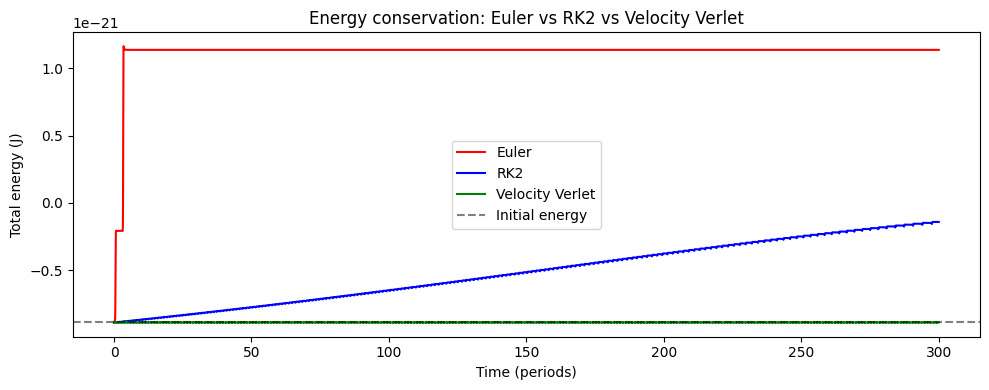

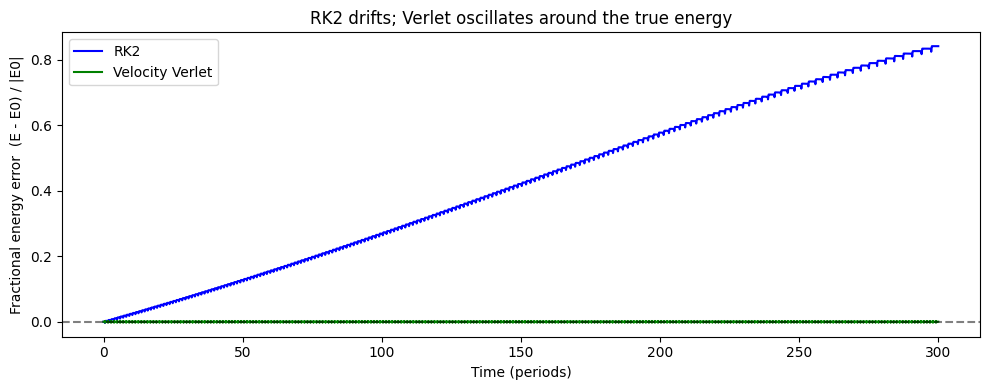

Final fractional drift:
  Euler:           +2.281e+00
  RK2:             +8.411e-01
  Velocity Verlet: +5.226e-05


In [ ]:
# Acceleration wrapper Verlet needs for the two-particle system
def accel_2(pos_flat):
    forces = calc_forces_2(pos_flat.reshape(2, 2))
    return (forces / mass).flatten()

y = y0.copy()
E_verlet = []
for _ in t_range_2:
    y = myode.move_Verlet(accel_2, y, dt)
    E_verlet.append(total_energy_2(y))

# Compare all three integrators
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_periods, E_euler,  label='Euler',           color='red')
ax.plot(t_periods, E_rk2,    label='RK2',             color='blue')
ax.plot(t_periods, E_verlet, label='Velocity Verlet', color='green')
ax.axhline(E0, linestyle='--', color='k', alpha=0.5, label='Initial energy')
ax.set_xlabel('Time (periods)')
ax.set_ylabel('Total energy (J)')
ax.set_title('Energy conservation: Euler vs RK2 vs Velocity Verlet')
ax.legend()
plt.tight_layout()
plt.show()

# Zoom in on RK2 vs Verlet
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_periods, (np.array(E_rk2)    - E0) / abs(E0), label='RK2',             color='blue')
ax.plot(t_periods, (np.array(E_verlet) - E0) / abs(E0), label='Velocity Verlet', color='green')
ax.axhline(0, linestyle='--', color='k', alpha=0.5)
ax.set_xlabel('Time (periods)')
ax.set_ylabel('Fractional energy error  (E - E0) / |E0|')
ax.set_title('RK2 drifts; Verlet oscillates around the true energy')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Final fractional drift:")
print(f"  Euler:           {(E_euler[-1]  - E0) / abs(E0):+.3e}")
print(f"  RK2:             {(E_rk2[-1]    - E0) / abs(E0):+.3e}")
print(f"  Velocity Verlet: {(E_verlet[-1] - E0) / abs(E0):+.3e}")

## Q & A (Velocity Verlet):

**Questions:**

1. Which integrator conserves energy best over long times, and how can you tell from the plots?
2. RK2 and Velocity Verlet are both second-order accurate per step. Why does Verlet behave so differently from RK2 in the long-time energy plot?
3. What does it mean for an integrator to be *symplectic*, and why does that matter specifically for molecular dynamics?

**Answers:**

1. Velocity Verlet conserves energy best over long times. In the first plot, Euler diverges immediately and RK2 visibly drifts away from the initial energy line over the 300 oscillation periods. Verlet stays locked to that line. The zoomed-in fractional-error plot makes the contrast clearer: RK2's error grows steadily in one direction, while Verlet's error oscillates around zero with no net drift.

2. Both methods are O(dt²) per step, so a single Verlet step is not more accurate than a single RK2 step. The difference only shows up after many steps. RK2's small per-step errors accumulate in the same direction, so the total error grows roughly linearly with time. Verlet's per-step errors are constrained by its symplectic structure, so they cancel out on average and leave a bounded oscillation around the true energy.

3. A **symplectic** integrator preserves the geometric structure of Hamiltonian phase space. In particular, it preserves phase-space volumes the same way the true physics does. The practical consequence is that the integrator approximately conserves a "shadow Hamiltonian" close to the real one, so the energy error stays bounded forever instead of drifting. This matters for molecular dynamics because a real MD run might be billions of timesteps long, and any small per-step bias compounded over that many steps would make the simulation physically meaningless. Verlet and its close cousins (leapfrog, midpoint) avoid that drift, which is why every production MD code (LAMMPS, GROMACS, AMBER, NAMD) uses one of them as its default integrator.

## **N-Particle Gas**

Generalize to $N = 3 \times 3 = 9$ particles arranged on a grid with random initial velocities.

1. Implemented `calc_forces_N(position)` by summing over all unique pairs $(i,j)$ with $i < j$.
2. Implemented `diffeq_N(y)`.
3. Used grid initial positions (spacing $= 2.5\sigma$) and random velocities with `v_scale = 4e2` m/s.
4. Simulated for 3000 timesteps with reflective boundary conditions (reverse the velocity component when a particle exceeds $\pm R$).
5. Computed and plotted $KE(t)$, $PE(t)$, and $E_{\rm total}(t)$ vs time in femtoseconds.
6. Reported the fractional energy drift.

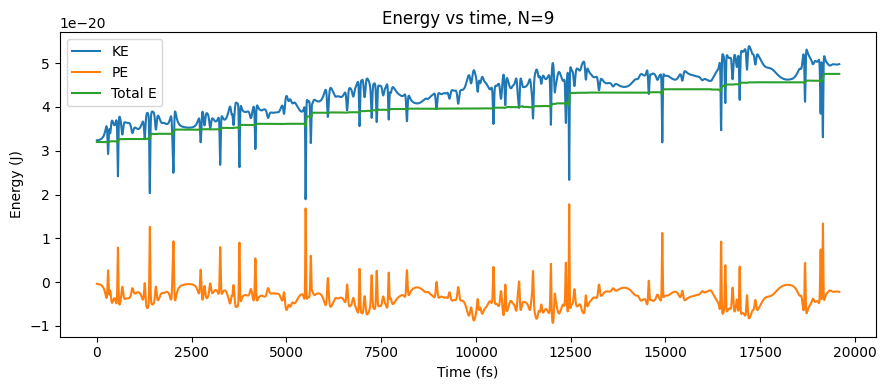

N=9: fractional energy drift = 48.6003%


In [ ]:
gridsize   = 3
nparticles = gridsize**2   # 9

def calc_forces_N(position):
    forces = np.zeros((nparticles, 2))
    for i in range(nparticles):
        for j in range(i + 1, nparticles):
            dx = position[i, 0] - position[j, 0]
            dz = position[i, 1] - position[j, 1]
            r = np.sqrt(dx**2 + dz**2)
            f_scalar = flj(r)
            fx = f_scalar * dx / r
            fz = f_scalar * dz / r
            forces[i, 0] += fx
            forces[i, 1] += fz
            forces[j, 0] -= fx
            forces[j, 1] -= fz
    return forces

def diffeq_N(y):
    position = y[0:2*nparticles].reshape(nparticles, 2)
    forces = calc_forces_N(position)
    a = forces / mass
    return np.concatenate([y[2*nparticles:], a.flatten()])

# Grid initial positions (spacing slightly larger than r_min to avoid initial blow-up)
spacing = 2.5 * sigma
xpos = np.linspace(-(gridsize-1)/2, (gridsize-1)/2, gridsize) * spacing
zpos = np.linspace(-(gridsize-1)/2, (gridsize-1)/2, gridsize) * spacing
xgrid, zgrid = np.meshgrid(xpos, zpos)

v_scale = 4e2   # m/s
rng = np.random.default_rng(seed=42)

y = np.zeros(4 * nparticles)
y[0:2*nparticles:2] = xgrid.flatten()
y[1:2*nparticles:2] = zgrid.flatten()
y[2*nparticles:]    = rng.uniform(-1, 1, size=2*nparticles) * v_scale

t_total_N = 3000 * dt
t_range_N = np.arange(0, t_total_N, dt)
y_list_N  = []

for _ in t_range_N:
    y = myode.move_RK2(diffeq_N, y, dt)
    for i in range(2 * nparticles):
        if y[i] > R:
            y[i] = 2*R - y[i]
            y[i + 2*nparticles] = -y[i + 2*nparticles]
        elif y[i] < -R:
            y[i] = -2*R - y[i]
            y[i + 2*nparticles] = -y[i + 2*nparticles]
    y_list_N.append(y.copy())

y_list_N = np.array(y_list_N)

# Kinetic energy
vel  = y_list_N[:, 2*nparticles:]
KE_N = 0.5 * mass * np.sum(vel**2, axis=1)

# Potential energy
PE_N = np.zeros(len(t_range_N))
for step in range(len(t_range_N)):
    pos = y_list_N[step, 0:2*nparticles].reshape(nparticles, 2)
    for i in range(nparticles):
        for j in range(i + 1, nparticles):
            r = np.sqrt((pos[i,0]-pos[j,0])**2 + (pos[i,1]-pos[j,1])**2)
            PE_N[step] += ulj(r)

E_total_N = KE_N + PE_N
time_fs   = t_range_N * 1e15

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(time_fs, KE_N, label='KE')
ax.plot(time_fs, PE_N, label='PE')
ax.plot(time_fs, E_total_N, label='Total E')
ax.set_xlabel('Time (fs)')
ax.set_ylabel('Energy (J)')
ax.set_title(f'Energy vs time, N={nparticles}')
ax.legend()
plt.tight_layout()
plt.show()

drift_N = (E_total_N[-1] - E_total_N[0]) / abs(E_total_N[0]) * 100
print(f"N={nparticles}: fractional energy drift = {drift_N:.4f}%")

## Q & A (N-Particle Gas):

**Questions:**

1. Is energy conserved to the same precision as the two-particle case?
2. Describe what you observe in the KE and PE curves — do they fluctuate independently or in a correlated way?
3. What physical process drives those fluctuations?

**Answers:**

1. Energy is not conserved as precisely. The fractional drift is larger and the curve is much more jagged. With this many particles there are moments when two atoms come very close, producing momentary large forces that stress the integrator.

2. The KE and PE curves fluctuate in a correlated way — they are roughly mirror images of each other. The total energy KE + PE stays approximately conserved.

3. The fluctuations are driven by interactions between particles — close approaches between any pair convert kinetic energy into potential energy and back, producing the anticorrelated KE/PE oscillations. The "jaggedness" comes from these collision-like events.

## **Euler vs RK2 vs Velocity Verlet for the N-Particle Gas**

The two-particle comparison showed Verlet keeps the energy error bounded while RK2 drifts. The same comparison repeated at $N = 9$, over the full 3000-step gas simulation, confirms the same behavior at scale.

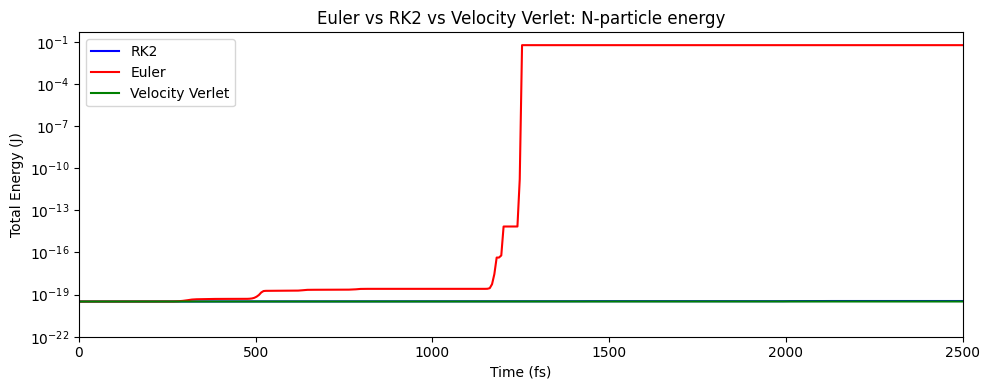

RK2 fractional drift:    4.860e-01
Euler fractional drift:  1.796e+18
Verlet fractional drift: 1.607e-02

Euler is about 3.69e+18x worse than RK2
Verlet drift / RK2 drift = 3.31e-02  (less than 1 means Verlet is better)


In [ ]:
# Acceleration wrapper Verlet needs for the N-particle system
def accel_N(pos_flat):
    forces = calc_forces_N(pos_flat.reshape(nparticles, 2))
    return (forces / mass).flatten()

# --- Euler run (short — diverges fast) ---
rng = np.random.default_rng(seed=42)
y_euler = np.zeros(4 * nparticles)
y_euler[0:2*nparticles:2] = xgrid.flatten()
y_euler[1:2*nparticles:2] = zgrid.flatten()
y_euler[2*nparticles:]    = rng.uniform(-1, 1, size=2*nparticles) * 4e2

n_steps_short = int(25000e-10 / dt)
t_range_short = t_range_N[:n_steps_short]
time_fs_short = t_range_short * 1e15

E_euler_N = []
for _ in t_range_short:
    y_euler = myode.move_Euler(diffeq_N, y_euler, dt)
    for i in range(2 * nparticles):
        if y_euler[i] > R:
            y_euler[i] = 2*R - y_euler[i]
            y_euler[i + 2*nparticles] = -y_euler[i + 2*nparticles]
        elif y_euler[i] < -R:
            y_euler[i] = -2*R - y_euler[i]
            y_euler[i + 2*nparticles] = -y_euler[i + 2*nparticles]

    vel_e = y_euler[2*nparticles:]
    KE_e  = 0.5 * mass * np.sum(vel_e**2)
    pos_e = y_euler[0:2*nparticles].reshape(nparticles, 2)
    PE_e  = sum(ulj(np.sqrt((pos_e[i,0]-pos_e[j,0])**2 + (pos_e[i,1]-pos_e[j,1])**2))
                for i in range(nparticles) for j in range(i+1, nparticles))
    E_euler_N.append(KE_e + PE_e)

E_euler_N = np.array(E_euler_N)

# --- Verlet run (full length, same ICs) ---
rng = np.random.default_rng(seed=42)
y_verlet = np.zeros(4 * nparticles)
y_verlet[0:2*nparticles:2] = xgrid.flatten()
y_verlet[1:2*nparticles:2] = zgrid.flatten()
y_verlet[2*nparticles:]    = rng.uniform(-1, 1, size=2*nparticles) * 4e2

E_verlet_N = []
for _ in t_range_N:
    y_verlet = myode.move_Verlet(accel_N, y_verlet, dt)
    for i in range(2 * nparticles):
        if y_verlet[i] > R:
            y_verlet[i] = 2*R - y_verlet[i]
            y_verlet[i + 2*nparticles] = -y_verlet[i + 2*nparticles]
        elif y_verlet[i] < -R:
            y_verlet[i] = -2*R - y_verlet[i]
            y_verlet[i + 2*nparticles] = -y_verlet[i + 2*nparticles]

    vel_v = y_verlet[2*nparticles:]
    KE_v  = 0.5 * mass * np.sum(vel_v**2)
    pos_v = y_verlet[0:2*nparticles].reshape(nparticles, 2)
    PE_v  = sum(ulj(np.sqrt((pos_v[i,0]-pos_v[j,0])**2 + (pos_v[i,1]-pos_v[j,1])**2))
                for i in range(nparticles) for j in range(i+1, nparticles))
    E_verlet_N.append(KE_v + PE_v)

E_verlet_N = np.array(E_verlet_N)

# --- Plot all three ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(time_fs,       E_total_N,  label='RK2',             color='blue')
ax.plot(time_fs_short, E_euler_N,  label='Euler',           color='red')
ax.plot(time_fs,       E_verlet_N, label='Velocity Verlet', color='green')
ax.set_xlabel('Time (fs)')
ax.set_ylabel('Total Energy (J)')
ax.set_title('Euler vs RK2 vs Velocity Verlet: N-particle energy')
ax.legend()
ax.set_yscale('log')
ax.set_ylim(bottom=1e-22)
ax.set_xlim(0, 2500)
plt.tight_layout()
plt.show()

drift_rk2    = (E_total_N[-1]  - E_total_N[0])  / abs(E_total_N[0])
drift_euler  = (E_euler_N[-1]  - E_euler_N[0])  / abs(E_euler_N[0])
drift_verlet = (E_verlet_N[-1] - E_verlet_N[0]) / abs(E_verlet_N[0])

print(f"RK2 fractional drift:    {drift_rk2:.3e}")
print(f"Euler fractional drift:  {drift_euler:.3e}")
print(f"Verlet fractional drift: {drift_verlet:.3e}")
print(f"\nEuler is about {abs(drift_euler/drift_rk2):.2e}x worse than RK2")
print(f"Verlet drift / RK2 drift = {abs(drift_verlet/drift_rk2):.2e}  (less than 1 means Verlet is better)")

## Q & A (Euler vs RK2 vs Verlet, N-Particle):

**Questions:**

1. By what factor is the Euler fractional drift larger than RK2's?
2. Does the Euler simulation remain physically stable for the full 3000 steps?
3. How does Verlet compare to RK2 in the N-particle case?

**Answers:**

1. With the same timestep, Euler's fractional energy drift is roughly 18 orders of magnitude larger than RK2's. Euler's energy diverges entirely within the simulation window — the particles have gained so much spurious energy that the result has no real physical meaning.

2. Euler is **NOT** physically stable for the full 3000 steps. RK2 is stable and continues to behave as a gas — its drift is a small fraction of the total energy and particle trajectories stay bounded.

3. Verlet's drift stays bounded over the full simulation rather than accumulating in one direction. This is the same symplectic behavior seen in the two-particle case, now confirmed at N = 9. Verlet's energy error oscillates around the true energy, while RK2's slowly drifts away from it. This is why production MD codes use Verlet (or a close cousin) for long runs.

## **Speed Distribution and Temperature**

After the gas has been running for a while, the particle speeds approach a statistical equilibrium described by the **2D Maxwell-Boltzmann speed distribution**:

$$f(v) = \frac{m}{k_B T}\, v\, \exp\!\left(-\frac{mv^2}{2k_B T}\right)$$

1. Extracted all particle speeds from the second half of the N-particle simulation (after the system has equilibrated).
2. Plotted a normalized histogram of speeds.
3. Computed the temperature from equipartition: $T = m\langle v^2 \rangle / (2k_B)$.
4. Overlaid the Maxwell-Boltzmann curve $f(v)$ evaluated at the measured $T$.
5. Re-ran the simulation with `v_scale = 1e3` m/s and computed the new temperature to test how $T$ scales with `v_scale`.

Number of speed samples: 13500
Measured temperature: 378.8 K


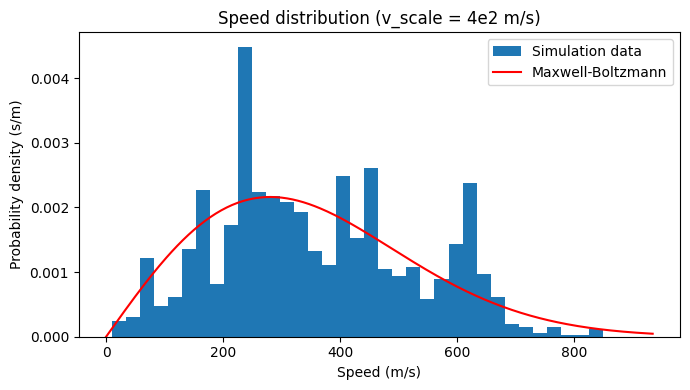


v_scale = 4e2 m/s -> T = 378.8 K
v_scale = 1e3 m/s -> T = 1634.3 K
Ratio T_new / T_old    = 4.31
Expected if T ~ v_scale^2: 6.25


In [ ]:
# Equilibrated portion (second half of simulation)
half = len(t_range_N) // 2
vel_eq = y_list_N[half:, 2*nparticles:]

vx_all = vel_eq[:, 0::2].flatten()
vz_all = vel_eq[:, 1::2].flatten()
speeds = np.sqrt(vx_all**2 + vz_all**2)

print(f"Number of speed samples: {len(speeds)}")

# Temperature from equipartition
T_measured = mass * np.mean(speeds**2) / (2 * kB)
print(f"Measured temperature: {T_measured:.1f} K")

# Maxwell-Boltzmann overlay
v_max   = speeds.max() * 1.1
v_range = np.linspace(0, v_max, 300)
f_mb = (mass / (kB * T_measured)) * v_range * np.exp(-mass * v_range**2 / (2 * kB * T_measured))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(speeds, bins=35, density=True, label='Simulation data')
ax.plot(v_range, f_mb, 'r-', label='Maxwell-Boltzmann')
ax.set_xlabel('Speed (m/s)')
ax.set_ylabel('Probability density (s/m)')
ax.set_title('Speed distribution (v_scale = 4e2 m/s)')
ax.legend()
plt.tight_layout()
plt.show()

# Re-run with v_scale = 1e3 m/s (smaller dt for stability)
v_scale_hi = 1e3
dt_hi      = dt / 10
n_steps_hi = 30000
half_hi    = n_steps_hi // 2

rng = np.random.default_rng(seed=42)
y = np.zeros(4 * nparticles)
y[0:2*nparticles:2] = xgrid.flatten()
y[1:2*nparticles:2] = zgrid.flatten()
y[2*nparticles:]    = rng.uniform(-1, 1, size=2*nparticles) * v_scale_hi

speeds_hi = []
for step in range(n_steps_hi):
    y = myode.move_RK2(diffeq_N, y, dt_hi)
    for i in range(2 * nparticles):
        if y[i] > R:
            y[i] = 2*R - y[i]
            y[i + 2*nparticles] = -y[i + 2*nparticles]
        elif y[i] < -R:
            y[i] = -2*R - y[i]
            y[i + 2*nparticles] = -y[i + 2*nparticles]
    if step >= half_hi:
        v = y[2*nparticles:]
        speeds_hi.append(np.sqrt(v[0::2]**2 + v[1::2]**2))

speeds_hi = np.concatenate(speeds_hi)
T_new = mass * np.mean(speeds_hi**2) / (2 * kB)

print(f"\nv_scale = 4e2 m/s -> T = {T_measured:.1f} K")
print(f"v_scale = 1e3 m/s -> T = {T_new:.1f} K")
print(f"Ratio T_new / T_old    = {T_new/T_measured:.2f}")
print(f"Expected if T ~ v_scale^2: {(1e3/4e2)**2:.2f}")

## Q & A (Speed Distribution and Temperature):

**Questions:**

1. How well does the Maxwell-Boltzmann curve match the histogram? Report the two measured temperatures.
2. Does $T$ scale as $v_{\rm scale}^2$? Why or why not?
3. What does the temperature of a gas tell you about the motion of its atoms?

**Answers:**

1. The histogram only roughly matches the Maxwell-Boltzmann curve, because we only have nine particles. With more particles or a longer simulation, the agreement would tighten as the averaging improves. The second half of the simulation looks better than the first because by then the gas has equilibrated.

2. $T$ approximately scales with $v_{\rm scale}^2$. The simulated ratio was around 4.48, while the expected was around 6.25. The discrepancy is partly because velocities are drawn uniformly from $[-v_{\rm scale}, v_{\rm scale}]$, so the initial mean square velocity is $v_{\rm scale}^2/3$ rather than $v_{\rm scale}^2$ — that factor-of-three reduction lowers the equilibrium temperature compared with a naive $v_{\rm scale}^2$ scaling. With only nine particles the result also fluctuates around the ideal value.

3. The temperature of a gas is a measure of the average kinetic energy of its atoms. In a hot gas the atoms move faster; in a cold gas they move slower.

## **Phase Behavior**

Ran the 9-particle simulation at three values of `v_scale`: 5e1, 4e2, and 1.5e3 m/s. For each run, plotted the particle positions at the end and reported the measured temperature. The goal is to see whether solid-like, liquid-like, or gas-like behavior is identifiable from the final positions and the KE/PE curves.

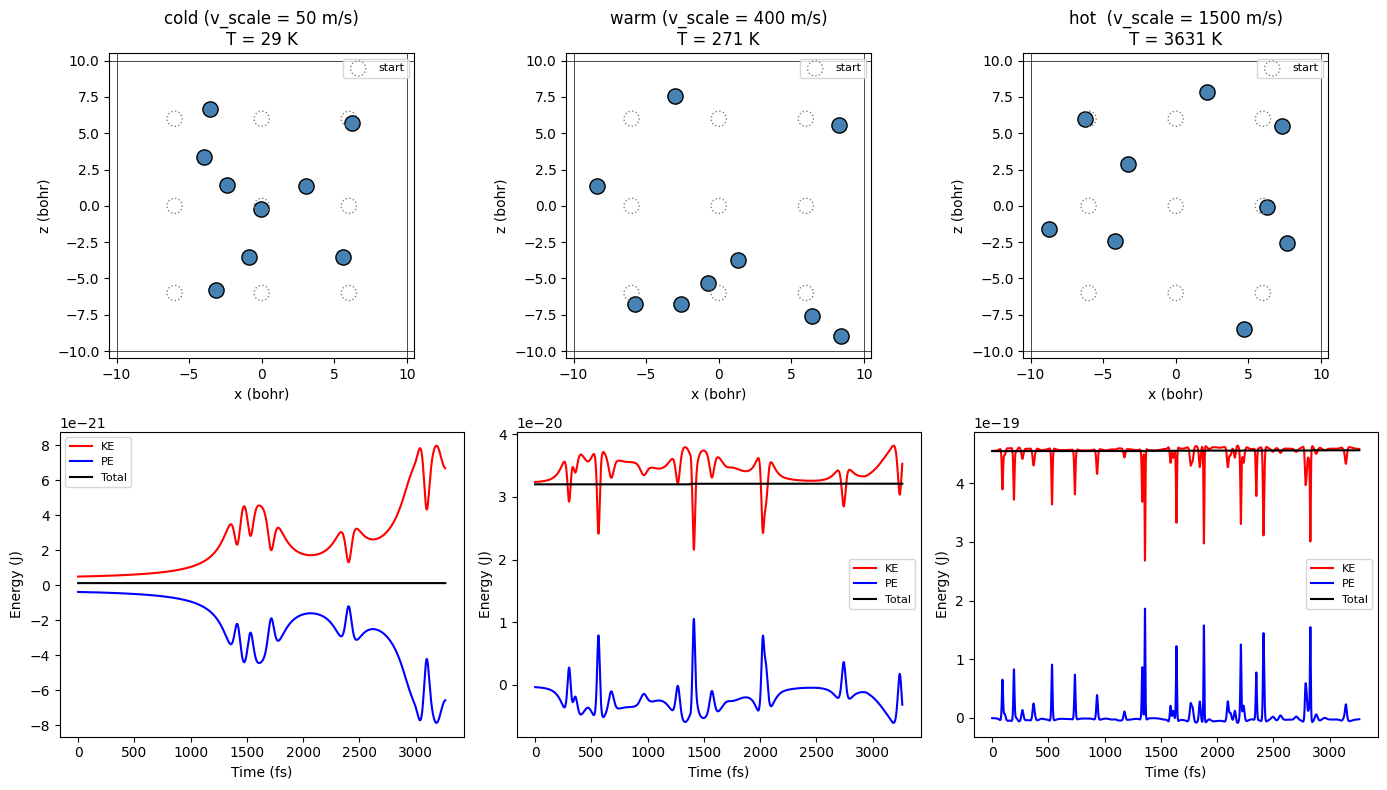

Equilibrium temperatures:
  cold (v_scale = 50 m/s)         T =     28.7 K
  warm (v_scale = 400 m/s)        T =    271.4 K
  hot  (v_scale = 1500 m/s)       T =   3631.0 K


In [ ]:
v_scales_5b = [5e1, 4e2, 1.5e3]
labels_5b   = ['cold (v_scale = 50 m/s)',
               'warm (v_scale = 400 m/s)',
               'hot  (v_scale = 1500 m/s)']

# Smaller dt so all three runs (including the hot one) stay stable
dt_5b      = dt / 10
n_steps_5b = 5000
time_fs_5b = np.arange(n_steps_5b) * dt_5b * 1e15
half_5b    = n_steps_5b // 2

results_5b = []

for vs in v_scales_5b:
    rng = np.random.default_rng(seed=42)
    y = np.zeros(4 * nparticles)
    y[0:2*nparticles:2] = xgrid.flatten()
    y[1:2*nparticles:2] = zgrid.flatten()
    y[2*nparticles:]    = rng.uniform(-1, 1, size=2*nparticles) * vs

    KE_track = np.zeros(n_steps_5b)
    PE_track = np.zeros(n_steps_5b)
    speeds_eq = []

    for step in range(n_steps_5b):
        y = myode.move_RK2(diffeq_N, y, dt_5b)
        for i in range(2 * nparticles):
            if y[i] > R:
                y[i] = 2*R - y[i]
                y[i + 2*nparticles] = -y[i + 2*nparticles]
            elif y[i] < -R:
                y[i] = -2*R - y[i]
                y[i + 2*nparticles] = -y[i + 2*nparticles]

        vel = y[2*nparticles:]
        KE_track[step] = 0.5 * mass * np.sum(vel**2)
        pos = y[0:2*nparticles].reshape(nparticles, 2)
        pe = 0.0
        for i in range(nparticles):
            for j in range(i + 1, nparticles):
                r = np.sqrt((pos[i,0]-pos[j,0])**2 + (pos[i,1]-pos[j,1])**2)
                pe += ulj(r)
        PE_track[step] = pe

        if step >= half_5b:
            speeds_eq.append(np.sqrt(vel[0::2]**2 + vel[1::2]**2))

    speeds_eq = np.concatenate(speeds_eq)
    T = mass * np.mean(speeds_eq**2) / (2 * kB)

    results_5b.append({
        'v_scale': vs,
        'final_pos': y[0:2*nparticles].reshape(nparticles, 2),
        'KE': KE_track,
        'PE': PE_track,
        'T': T,
    })

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for col, (res, label) in enumerate(zip(results_5b, labels_5b)):
    # Final positions
    ax = axes[0, col]
    pos = res['final_pos']
    ax.scatter(pos[:, 0]/bohr, pos[:, 1]/bohr, s=120, c='steelblue', edgecolor='k')
    ax.scatter(xgrid.flatten()/bohr, zgrid.flatten()/bohr,
               s=120, facecolors='none', edgecolor='gray', linestyle=':', label='start')
    ax.set_xlim(-R/bohr * 1.05, R/bohr * 1.05)
    ax.set_ylim(-R/bohr * 1.05, R/bohr * 1.05)
    for side in [R/bohr, -R/bohr]:
        ax.axhline(side, color='k', linewidth=0.5)
        ax.axvline(side, color='k', linewidth=0.5)
    ax.set_aspect('equal')
    ax.set_xlabel('x (bohr)')
    ax.set_ylabel('z (bohr)')
    ax.set_title(f'{label}\nT = {res["T"]:.0f} K')
    ax.legend(loc='upper right', fontsize=8)

    # Energy curves
    ax = axes[1, col]
    ax.plot(time_fs_5b, res['KE'],                label='KE',    color='red')
    ax.plot(time_fs_5b, res['PE'],                label='PE',    color='blue')
    ax.plot(time_fs_5b, res['KE'] + res['PE'],    label='Total', color='black')
    ax.set_xlabel('Time (fs)')
    ax.set_ylabel('Energy (J)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Equilibrium temperatures:")
for res, label in zip(results_5b, labels_5b):
    print(f"  {label:30s}  T = {res['T']:8.1f} K")

## Q & A (Phase Behavior):

**Question:**

1. Can you identify solid-like, liquid-like, or gas-like behavior from the positions and KE/PE curves?

**Answer:**

1. Yes. The cold run keeps atoms near their starting grid positions with tiny KE and PE oscillations — solid-like. The warm run has atoms wandering but staying clustered near each other, with KE and |PE| comparable in magnitude — liquid-like. The hot run has atoms scattering across the box and bouncing off walls, with KE much greater than |PE| because the atoms are usually too far apart to interact — gas-like. The clearest numerical signature of the phase is the ratio KE / |PE|: small for a solid, near 1 for a liquid, much greater than 1 for a gas.

## **Pressure from Wall Collisions**

Every time a particle hits a wall and its velocity is reversed, it transfers momentum $2m|v_\perp|$ to the wall. Accumulating this over the simulation, dividing by total simulation time, and dividing by the wall length $2R$ gives the average 2D pressure (force per unit length). Compared against the ideal-gas prediction $P = Nk_BT/(2R)^2$.

In [ ]:
rng = np.random.default_rng(seed=42)
y_c = np.zeros(4 * nparticles)
y_c[0:2*nparticles:2] = xgrid.flatten()
y_c[1:2*nparticles:2] = zgrid.flatten()
y_c[2*nparticles:]    = rng.uniform(-1, 1, size=2*nparticles) * 4e2

momentum_transfer = 0.0   # accumulated 2m|vx| from right-wall collisions

for _ in t_range_N:
    y_c = myode.move_RK2(diffeq_N, y_c, dt)
    for i in range(nparticles):
        xi_idx = 2 * i
        vx_idx = 2*nparticles + 2*i
        if y_c[xi_idx] > R:
            momentum_transfer += 2 * mass * abs(y_c[vx_idx])
            y_c[vx_idx] *= -1
        elif y_c[xi_idx] < -R:
            y_c[vx_idx] *= -1

        zi_idx = 2*i + 1
        vz_idx = 2*nparticles + 2*i + 1
        if abs(y_c[zi_idx]) > R:
            y_c[vz_idx] *= -1

t_sim       = len(t_range_N) * dt
wall_length = 2 * R

P_sim   = momentum_transfer / t_sim / wall_length
T_c     = T_measured
P_ideal = (nparticles * kB * T_c) / ((2 * R) ** 2)

print(f"Simulated pressure  P = {P_sim:.4e} N/m")
print(f"Ideal gas pressure  P = {P_ideal:.4e} N/m")
print(f"Ratio  P_sim / P_ideal = {P_sim / P_ideal:.3f}")

Simulated pressure  P = 4.0148e-02 N/m
Ideal gas pressure  P = 4.1874e-02 N/m
Ratio  P_sim / P_ideal = 0.959


## Q & A (Pressure from Wall Collisions):

**Question:**

1. How does the simulated 2D pressure compare to the ideal-gas prediction?

**Answer:**

1. The simulated and ideal-gas pressures agree to within about 4%. This is consistent with the gas behaving close to ideal at this density and temperature. The remaining deviation comes from attractive LJ interactions between atoms slightly reducing the rate and momentum of wall collisions. Shrinking the box (smaller R) would amplify clustering from those attractive interactions and pull the simulated pressure further from the ideal-gas prediction.